# Compare stim1 tuning across delay

Is number of untuned neurons similar across delay50 and delay150

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv



2025-06-23 12:31:36.702917: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 12:31:36.712460: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-23 12:31:36.722703: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-23 12:31:36.725796: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-23 12:31:36.734403: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = [50, 150]
condn_phrase = 'delay'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [ ]:
# get list of models with performance btwn 60-100% for longer delay

model_names, perfs = ld.get_models_by_perf(low_cutoff=0.60, high_cutoff=np.inf, 
                                              condn_phrase='delay', condn_num=150)
print(len(model_names), 'models with performance between 60-100% for delay 150')

Found 141 models with performance between 0.6 and inf
141 models with performance between 60-100% for delay 150


In [7]:
tuning = np.zeros((len(model_names), 200, 2))
for i, model_name in enumerate(model_names):
    tuning[i,:,0] = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, 50)
    tuning[i,:,1] = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, 150)

## Seeing how consistent tuning is, check 1 model

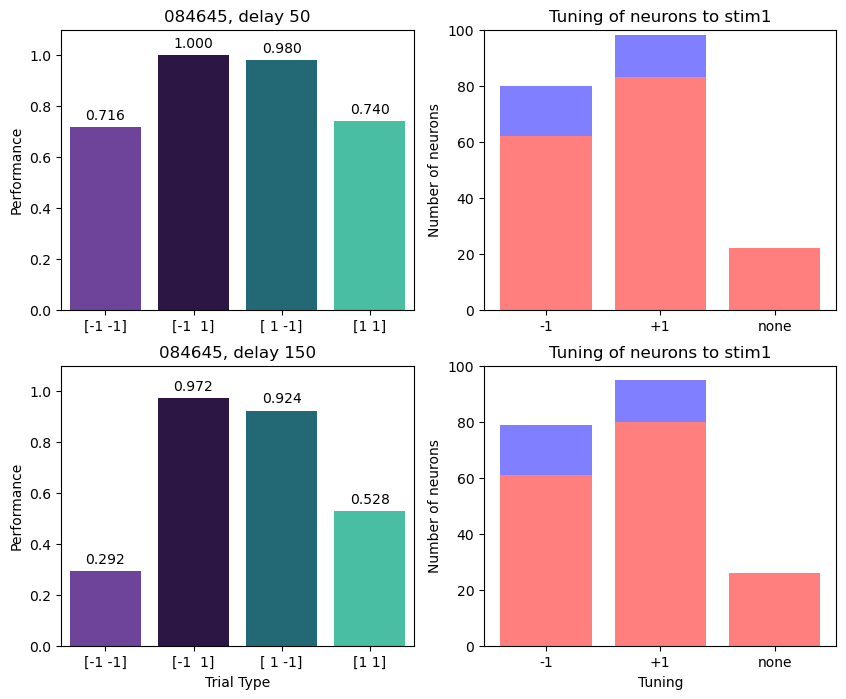

In [4]:
# choose model 1 to visualize for now — tuning calc via spikes
model_name = model_dirs[1]
model_dir = os.path.join(all_models_dir, model_name)

importlib.reload(sn)
tuning = np.zeros((200,2))
fig, axs = plt.subplots(2,2,figsize=(10,8), sharey='col')
for i, condn_num in enumerate(delay):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, ax=axs[i,0])
    tuning[:,i] = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num)
    exc_ind, inh_ind = ld.get_celltype_label(model_name)
    sn.plot_stim1_tuning(tuning[:,i], exc_ind=exc_ind, ax=axs[i,1])
axs[0,0].set_xlabel('')
axs[0,1].set_xlabel('');


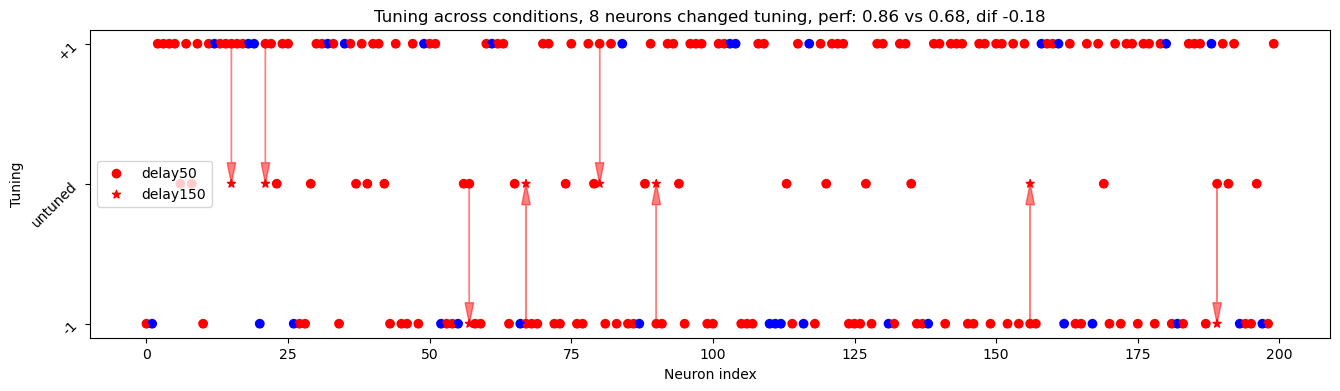

In [5]:
# plot how each neuron's tuning has changed from short to long delay

colors = ['r' if i in exc_ind else 'b' for i in range(200)]
shapes = ['o','*']

tuning[np.where(np.isnan(tuning))] = 0
plt.figure(figsize=(16,4))
perfs = []
for i, condn_num in enumerate(delay):
    plt.scatter(np.arange(200), tuning[:,i], c=colors, label=f"{condn_phrase}{condn_num}",
                marker=shapes[i])
    _, perf = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    perfs.append(np.mean(perf))
flip = np.where(tuning[:,0] != tuning[:,1])[0]
for i in flip:
    # plt.plot([i,i], [tuning[i,0], tuning[i,1]], c='k', alpha=0.5)
    plt.arrow(i, tuning[i,0], 0, tuning[i,1]-tuning[i,0], length_includes_head=True,
              head_width=1.5, head_length=0.15, fc=colors[i], ec=colors[i], alpha=0.5)
plt.xlabel('Neuron index')
plt.ylabel('Tuning')
plt.yticks([-1,0,1], labels=['-1','untuned','+1'], rotation=45)
plt.title(f'Tuning across conditions, {len(flip)} neurons changed tuning, perf: {perfs[0]:.2f} vs {perfs[1]:.2f}, dif {perfs[1]-perfs[0]:.2f}')
plt.legend()
plt.show()


## now across models

### number untuned

In [11]:
n_untuned = np.sum(np.isnan(tuning), axis=1)
n_untuned.shape

(141, 2)

Wilcoxon signed-rank test p-value: 0.8003


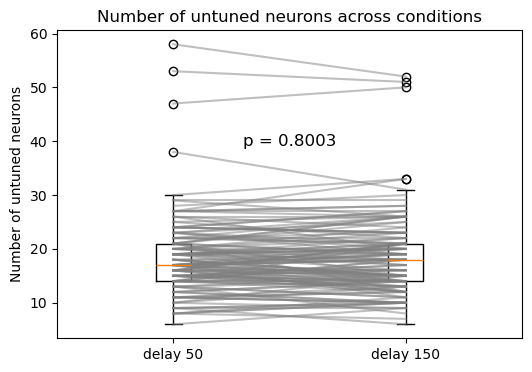

In [16]:
plt.figure(figsize=(6,4))
plt.boxplot([n_untuned[:,0], n_untuned[:,1]], positions=[0,1])
# draw gray lines
plt.plot(n_untuned.T, c='gray', alpha=0.5,)
# stats, wilcoxon sign-rank
_, pval = scipy.stats.wilcoxon(n_untuned[:,0], n_untuned[:,1])
print(f'Wilcoxon signed-rank test p-value: {pval:.4f}')
plt.text(0.5, 40, f'p = {pval:.4f}', ha='center', va='center', fontsize=12, color='black')

plt.xticks([0,1], [f'{condn_phrase} {delay[0]}', f'{condn_phrase} {delay[1]}'])
plt.ylabel('Number of untuned neurons')
plt.title(f'Number of untuned neurons across conditions')
plt.show()

In [23]:
# split up by how much worse models are at delay 150 — split by percentile

better_idx = np.where(perfs > np.percentile(perfs, 75))[0].astype(int)
worse_idx = np.where(perfs < np.percentile(perfs, 25))[0].astype(int)

print(f'Number of models better at delay 150: {len(better_idx)}, avg perf: {np.mean(perfs[better_idx]):.2f}')
print(f'Number of models worse at delay 150: {len(worse_idx)}, avg perf: {np.mean(perfs[worse_idx]):.2f}')

Number of models better at delay 150: 34, avg perf: 0.98
Number of models worse at delay 150: 35, avg perf: 0.74


([<matplotlib.axis.XTick at 0x72dec3c57ad0>,
 [Text(1, 0, 'better '), Text(2, 0, 'worse ')])

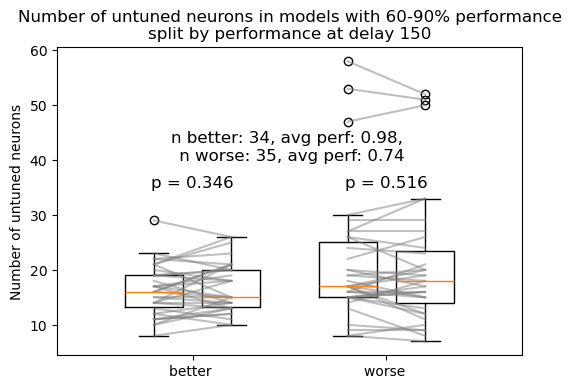

In [27]:
# make paired boxplot, now split by better/worse

plt.figure(figsize=(6,4))
plt.boxplot([n_untuned[better_idx,0], n_untuned[better_idx,1]], positions=[0.8, 1.2], widths=0.3)
plt.boxplot([n_untuned[worse_idx,0], n_untuned[worse_idx,1]], positions=[1.8, 2.2], widths=0.3)
# draw gray lines for each pair
for i in range(len(better_idx)):
    plt.plot([0.8, 1.2], [n_untuned[better_idx[i],0], n_untuned[better_idx[i],1]], color='gray', alpha=0.5)
for i in range(len(worse_idx)):
    plt.plot([1.8, 2.2], [n_untuned[worse_idx[i],0], n_untuned[worse_idx[i],1]], color='gray', alpha=0.5)
    
# do stats, wilcoxon signed-rank test for better and worse models
stat_better, pval_better = scipy.stats.wilcoxon(n_untuned[better_idx,0], n_untuned[better_idx,1])
stat_worse, pval_worse = scipy.stats.wilcoxon(n_untuned[worse_idx,0], n_untuned[worse_idx,1])
plt.text(1, 35, 'p = {:.3f}'.format(pval_better), fontsize=12, ha='center')
plt.text(2, 35, 'p = {:.3f}'.format(pval_worse), fontsize=12, ha='center')
plt.text(1.5, 40, f'n better: {len(better_idx)}, avg perf: {np.mean(perfs[better_idx]):.2f}, \n n worse: {len(worse_idx)}, avg perf: {np.mean(perfs[worse_idx]):.2f}',
         fontsize=12, ha='center')
    
plt.ylabel('Number of untuned neurons')
plt.title('Number of untuned neurons in models with 60-90% performance\n'
          'split by performance at delay 150')
plt.xticks([1, 2], ['better ', 'worse '], rotation=0)

([<matplotlib.axis.XTick at 0x72dec369a6d0>,
 [Text(1, 0, 'delay50 '), Text(2, 0, 'delay150 ')])

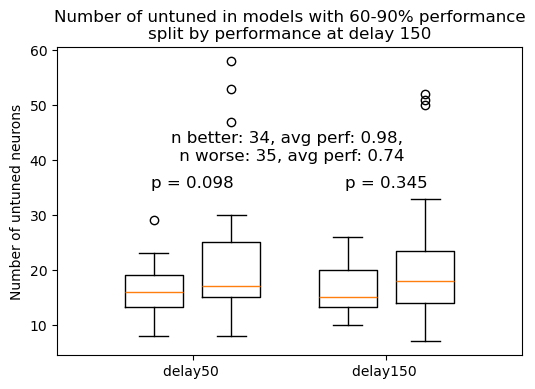

In [28]:
# make paired boxplot, now split by better/worse

plt.figure(figsize=(6,4))
plt.boxplot([n_untuned[better_idx,0], n_untuned[worse_idx,0]], positions=[0.8, 1.2], widths=0.3)
plt.boxplot([n_untuned[better_idx,1], n_untuned[worse_idx,1]], positions=[1.8, 2.2], widths=0.3)
    
# do stats, mann whitney
_, p_50 = scipy.stats.mannwhitneyu(n_untuned[better_idx,0], n_untuned[worse_idx,0])
_, p_150 = scipy.stats.mannwhitneyu(n_untuned[better_idx,1], n_untuned[worse_idx,1])
plt.text(1, 35, 'p = {:.3f}'.format(p_50), fontsize=12, ha='center')
plt.text(2, 35, 'p = {:.3f}'.format(p_150), fontsize=12, ha='center')
plt.text(1.5, 40, f'n better: {len(better_idx)}, avg perf: {np.mean(perfs[better_idx]):.2f}, \n n worse: {len(worse_idx)}, avg perf: {np.mean(perfs[worse_idx]):.2f}',
         fontsize=12, ha='center')

plt.ylabel('Number of untuned neurons')
plt.title('Number of untuned in models with 60-90% performance\n'
          'split by performance at delay 150')
plt.xticks([1, 2], ['delay50 ', 'delay150 '], rotation=0)

### number switched btwn +1 and -1

In [17]:
n_flip = np.sum(tuning == tuning*-1, axis=1)
n_flip.shape

(141, 2)

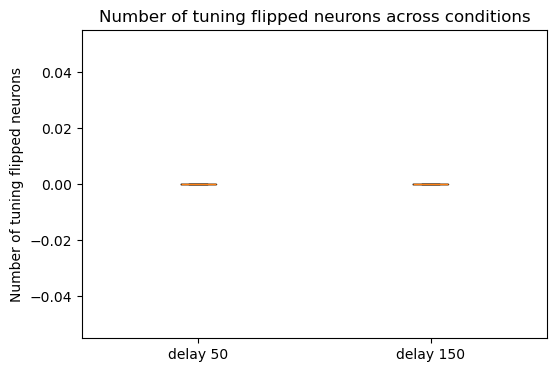

In [22]:
plt.figure(figsize=(6,4))
plt.boxplot([n_flip[:,0], n_flip[:,1]], positions=[0,1])
# draw gray lines
# plt.plot(n_flip.T, c='gray', alpha=0.5,)
# stats, wilcoxon sign-rank
# _, pval = scipy.stats.wilcoxon(n_flip[:,0], n_flip[:,1])
# print(f'Wilcoxon signed-rank test p-value: {pval:.4f}')
# plt.text(0.5, 40, f'p = {pval:.4f}', ha='center', va='center', fontsize=12, color='black')

plt.xticks([0,1], [f'{condn_phrase} {delay[0]}', f'{condn_phrase} {delay[1]}'])
plt.ylabel('Number of tuning flipped neurons')
plt.title(f'Number of tuning flipped neurons across conditions')
plt.show()